# Standard Random Forest Classifier - Diabetes Dataset

This notebook trains a standard (non-private) Random Forest classifier on the BRFSS 2015 Diabetes dataset to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
# Load preprocessed data
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (56553, 21)
Test data shape: (14139, 21)
Number of features: 21

Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## 3. Train Standard Random Forest Model

In [3]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training Standard Random Forest...")
_t0 = time.perf_counter()
rf_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = rf_model.predict(X_train)
print("✓ Training complete!")

Training Standard Random Forest...
✓ Training complete!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


## 4. Make Predictions

In [4]:
# Predictions on test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")

Predictions shape: (14139,)
Prediction probabilities shape: (14139, 2)


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


## 5. Model Evaluation

In [5]:
# Calculate metrics
extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=rf_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("="*60)
print("STANDARD RANDOM FOREST - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*60)

STANDARD RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.7373
F1-Score:  0.7471
Precision: 0.7202
Recall:    0.7761


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


## 6. Confusion Matrix

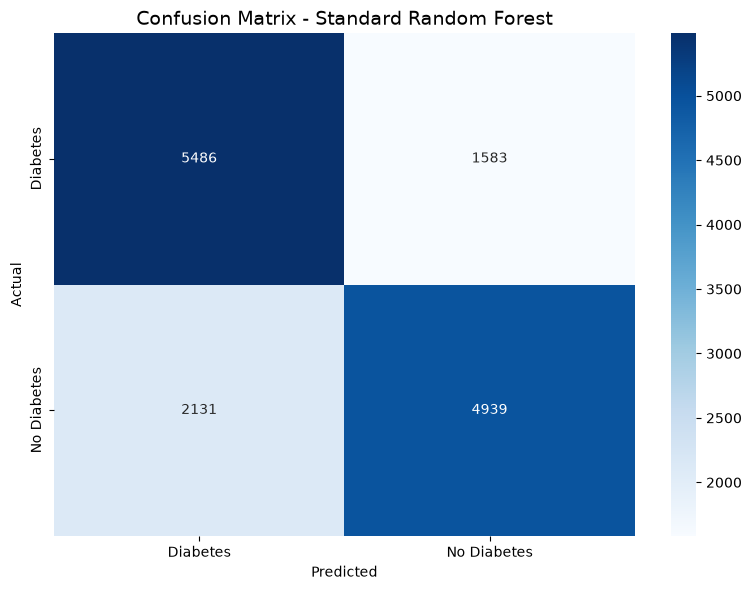


Confusion Matrix:
[[5486 1583]
 [2131 4939]]

True Positives (TP): 5486
False Negatives (FN): 1583
False Positives (FP): 2131
True Negatives (TN): 4939


In [6]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Rearrange for medical interpretation (TP, FN / FP, TN)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Diabetes', 'No Diabetes'],
            yticklabels=['Diabetes', 'No Diabetes'])
plt.title('Confusion Matrix - Standard Random Forest', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)
print(f"\nTrue Positives (TP): {TP}")
print(f"False Negatives (FN): {FN}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")

## 7. Classification Report

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Diabetes', 'Diabetes']))

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.70      0.73      7070
    Diabetes       0.72      0.78      0.75      7069

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.74     14139
weighted avg       0.74      0.74      0.74     14139



## 8. Feature Importance

Top 10 Most Important Features:
                 feature  importance
0                 HighBP    0.283230
13               GenHlth    0.221020
3                    BMI    0.154661
1               HighChol    0.138101
16              DiffWalk    0.064814
18                   Age    0.046093
15              PhysHlth    0.041824
6   HeartDiseaseorAttack    0.018666
20                Income    0.015138
10     HvyAlcoholConsump    0.004823


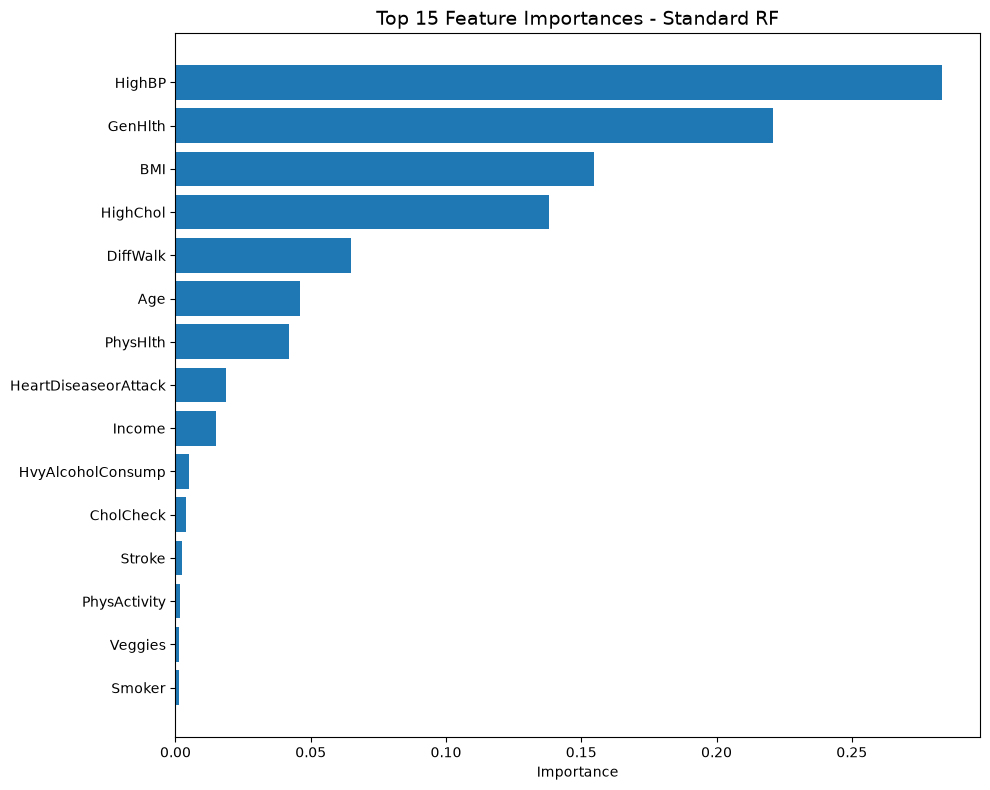

In [8]:
# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Standard RF', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Save Baseline Results

In [9]:
import os
os.makedirs('output', exist_ok=True)

# Save baseline metrics to CSV
baseline_results = pd.DataFrame({
    'model': ['Standard_RF'],
    'accuracy': [accuracy],
    'f1_score': [f1],
    'precision': [precision],
    'recall': [recall]
})

baseline_results.to_csv('output/baseline_results.csv', index=False)
print("✓ Baseline results saved to 'output/baseline_results.csv'")

# Save detailed report to JSON
report = {
    'model_type': 'Standard Random Forest',
    'dataset': 'BRFSS 2015 Diabetes',
    'parameters': {
        'n_estimators': 20,
        'max_depth': 4,
        'random_state': 42
    },
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    },
    'confusion_matrix': custom_cm.tolist(),
    'feature_importance': feature_importance_df.to_dict('records')
}
report.update(extra.means())

with open('output/std_rf_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("✓ Detailed report saved to 'output/std_rf_report.json'")

print("Added metrics:")
print(extra.describe())

✓ Baseline results saved to 'output/baseline_results.csv'
✓ Detailed report saved to 'output/std_rf_report.json'
Added metrics:
  Train Acc:      0.7410 ± 0.0000
  Balanced Acc:   0.7373 ± 0.0000
  AUROC:          0.8129 ± 0.0000
  Train Time (s): 0.1091 ± 0.0000


In [10]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(rf_model, 'output/model/std_rf_model.pkl')

Model successfully exported to output/model/std_rf_model.pkl


## 10. Summary

In [11]:
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard Random Forest")
print(f"Dataset: BRFSS 2015 Diabetes ({X_train.shape[0]:,} train, {X_test.shape[0]:,} test)")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"\n✓ Baseline established for DP comparison")
print("="*60)


BASELINE MODEL SUMMARY
Model: Standard Random Forest
Dataset: BRFSS 2015 Diabetes (56,553 train, 14,139 test)

Performance Metrics:
  Accuracy:  0.7373
  F1-Score:  0.7471
  Precision: 0.7202
  Recall:    0.7761

✓ Baseline established for DP comparison
